<a href="https://colab.research.google.com/github/aravinth-xuno/fraud-detection-notebook/blob/main/Exploratory_Data_Analysis_for_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports the `drive` module from `google.colab` and mounts Google Drive to the `/content/drive` directory, allowing access to files stored in Google Drive.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

### Data Loading
This section loads the transaction dataset from Google Drive for further analysis.

In [3]:
df = pd.read_csv('/content/drive/Shareddrives/transaction-training-set/dataset/txn_prod_2026-04-06.csv', low_memory = False)

### Data Inspection
We will now use `df.head()` to view the first 5 rows of the dataset. This helps us verify that the data was loaded correctly and observe the values in each column.

In [4]:
display(df.head())
# Displaying the first 5 rows to see the raw data structure.

,TRANSACTION_KEY,ID,DOCUMENT_NUMBER,TRANSACTION_TYPE,PAYMENT_STRUCTURE_KEY,DEVICE_ID,SENDER_COUNTRY_KEY,SENDER_CURRENCY_KEY,SENDER_KEY,SENDER_ACCOUNT_KEY,...,EXCHANGE_RATE,TOTAL_FEES_ADDED,TOTAL_FEES_DEDUCTED,PAYMENT_FEE_ADDED,PAYOUT_FEE_ADDED,DELIVERY_SPEED_FEE_ADDED,INITIATED_AT,STATUS,USER_ID,TRANSACTION_COMPLETED_AT
0,4205277,87589,MC-90001858-0006,ACH_TRANSFER,NaN,NaN,102,102,134859,23480,...,107.27,NaN,NaN,0.00,NaN,NaN,2016-12-26T06:11:05,DELIVERED,67f139306b43913e05bc42e8,2017-01-03T00:39:27
1,4166124,32080,TR-90000428-0026,ACH_TRANSFER,NaN,NaN,102,102,121749,2248,...,116.43,NaN,NaN,0.00,NaN,NaN,2018-10-22T14:44:41,DELIVERED,67f0e97a9674261dc694ea15,2018-10-29T13:11:58
2,4293600,139203,TR-90002354-0033,ACH_TRANSFER,NaN,NaN,102,102,121266,12952,...,129.55,NaN,NaN,0.00,NaN,NaN,2023-04-10T05:35:33,DELIVERED,67f0e7a29674261dc694de4f,2023-04-17T07:21:02
3,4196980,53061,TR-90000024-0161,ACH_TRANSFER,NaN,NaN,102,102,125591,7775,...,120.11,NaN,NaN,0.00,NaN,NaN,2020-03-25T04:11:43,DELIVERED,67f0ed5d6b43913e05bbbe06,2020-04-06T10:51:34
4,4274602,120847,TR-70001473-0079,ACH_TRANSFER,NaN,NaN,102,102,121448,23432,...,120.35,NaN,NaN,2.99,NaN,NaN,2022-03-10T14:07:36,DELIVERED,67f0e8089674261dc694e2b1,2022-03-16T07:05:37


### Dataset Information
The `df.info()` method provides a concise summary of the DataFrame, including the number of non-null entries in each column, the data types (e.g., int64, object), and memory usage.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180072 entries, 0 to 180071
Data columns (total 29 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   TRANSACTION_KEY                   180072 non-null  int64  
 1   ID                                180072 non-null  object 
 2   DOCUMENT_NUMBER                   180072 non-null  object 
 3   TRANSACTION_TYPE                  180072 non-null  object 
 4   PAYMENT_STRUCTURE_KEY             18210 non-null   float64
 5   DEVICE_ID                         13894 non-null   object 
 6   SENDER_COUNTRY_KEY                180072 non-null  int64  
 7   SENDER_CURRENCY_KEY               180072 non-null  int64  
 8   SENDER_KEY                        180072 non-null  int64  
 9   SENDER_ACCOUNT_KEY                180072 non-null  int64  
 10  SENDER_PAYMENT_INSTRUMENT_KEY     18260 non-null   float64
 11  RECIPIENT_CURRENCY_KEY            18260 non-null   f

### Statistical Summary
The `describe()` method generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution, excluding `NaN` values.

In [6]:
df.describe()

,TRANSACTION_KEY,PAYMENT_STRUCTURE_KEY,SENDER_COUNTRY_KEY,SENDER_CURRENCY_KEY,SENDER_KEY,SENDER_ACCOUNT_KEY,SENDER_PAYMENT_INSTRUMENT_KEY,RECIPIENT_CURRENCY_KEY,RECIPIENT_KEY,RECIPIENT_ACCOUNT_KEY,...,RECIPIENT_COUNTRY_KEY,SENDING_AMOUNT,TOTAL_DEBIT_AMOUNT,TOTAL_CREDIT_AMOUNT,EXCHANGE_RATE,TOTAL_FEES_ADDED,TOTAL_FEES_DEDUCTED,PAYMENT_FEE_ADDED,PAYOUT_FEE_ADDED,DELIVERY_SPEED_FEE_ADDED
count,1.800720e+05,18210.000000,180072.000000,180072.000000,180072.000000,180072.000000,18260.000000,18260.000000,18260.000000,18260.000000,...,18260.000000,180072.000000,18260.000000,1.800720e+05,180072.000000,32184.000000,18251.000000,180063.000000,18251.0,18251.0
mean,4.104723e+06,4.646129,102.001027,101.898596,124364.290612,27892.017387,9833.639321,101.985597,129850.056900,91875.501588,...,102.991238,1293.402847,1223.180497,1.522270e+05,118.017705,2.881476,4.661036,0.630353,0.0,0.0
std,6.003799e+05,5.656785,0.032036,0.301864,14219.167319,25962.468079,7080.915635,0.124102,17046.357123,8421.368574,...,0.099453,1826.419838,1833.505158,3.321974e+05,13.464343,6.465427,8.015668,1.530263,0.0,0.0
min,1.825226e+06,1.000000,102.000000,101.000000,0.000000,0.000000,0.000000,101.000000,0.000000,0.000000,...,101.000000,1.050000,10.000000,1.000000e+01,1.000000,-37.660000,0.000000,0.000000,0.0,0.0
25%,4.203775e+06,1.000000,102.000000,102.000000,119920.000000,5758.000000,3897.000000,102.000000,121144.000000,84704.000000,...,103.000000,250.000000,200.000000,2.928750e+04,108.000000,0.000000,0.000000,0.000000,0.0,0.0
50%,4.256024e+06,2.000000,102.000000,102.000000,127439.000000,22505.500000,7913.000000,102.000000,128484.000000,88566.000000,...,103.000000,550.000000,500.000000,6.697696e+04,115.380000,0.000000,1.940000,0.000000,0.0,0.0
75%,4.301042e+06,3.000000,102.000000,102.000000,133892.000000,45144.250000,14506.000000,102.000000,136571.000000,98610.000000,...,103.000000,1500.000000,1250.000000,1.656000e+05,130.300000,4.360000,5.500000,0.000000,0.0,0.0
max,4.469838e+06,16.000000,103.000000,102.000000,197613.000000,115919.000000,34907.000000,103.000000,197811.000000,116111.000000,...,103.000000,10000.000000,10000.000000,1.075639e+08,183.850000,83.770000,115.350000,27.980000,0.0,0.0


### Missing Values Analysis
Given the variations in non-null counts observed in `df.info()`, we will calculate the exact number of missing values for each column to identify data gaps.

In [7]:
df.isnull().sum()

,0
TRANSACTION_KEY,0
ID,0
DOCUMENT_NUMBER,0
TRANSACTION_TYPE,0
PAYMENT_STRUCTURE_KEY,161862
DEVICE_ID,166178
SENDER_COUNTRY_KEY,0
SENDER_CURRENCY_KEY,0
SENDER_KEY,0
SENDER_ACCOUNT_KEY,0


### Data Quality and Infrastructure Observations

Based on the missing value analysis, we can observe the following:

*   **Missing Identifiers**: There are **7 transactions** missing a `USER_ID` and **1 transaction** missing a `STATUS`.
*   **Infrastructure Hypothesis**: The count of **161,821** missing values repeats across multiple columns (e.g., `TOTAL_FEES_DEDUCTED`, `PAYOUT_FEE_ADDED`). This suggests these transactions may originate from an older infrastructure system where these specific data points were not captured.
*   **Transaction Split**:
    *   Total Transactions: 180,072
    *   Potential Old Infra Transactions: 161,821
    *   Active/New Infra Transactions: 18,251

### Duplicate and Unique Values Analysis
Finally, we will check for duplicate rows and count the unique values in categorical columns to understand the variety of transaction types and statuses.

In [23]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print("\nUnique values in TRANSACTION_TYPE:")
print(df['TRANSACTION_TYPE'].value_counts())
print("\nUnique values in STATUS:")
print(df['STATUS'].value_counts())

Number of duplicate rows: 0

Unique values in TRANSACTION_TYPE:
TRANSACTION_TYPE
ACH_TRANSFER             161812
STANDARD                  17802
OPEN_FORWARD_CONTRACT       320
WALLET_LOAD                 135
INTERNAL_TRANSFER             3
Name: count, dtype: int64

Unique values in STATUS:
STATUS
DELIVERED               151809
COMPLETED                16608
REFUNDED_CANCELED         9215
PENDING                   1142
CLEARING_FAILED            660
PROCESSING                 229
CANCELED                   195
CLEARING_SUCCESS            97
INITIATED                   61
RETURNED                    41
REFUNDED                     7
ON_HOLD                      5
PROCESSING_SUBMITTED         1
REVIEW_REQUIRED              1
Name: count, dtype: int64


### Transaction Type Visualization
We will now visualize the frequency of each transaction type using a horizontal bar plot. This helps us see the dominance of specific transaction methods like ACH transfers.

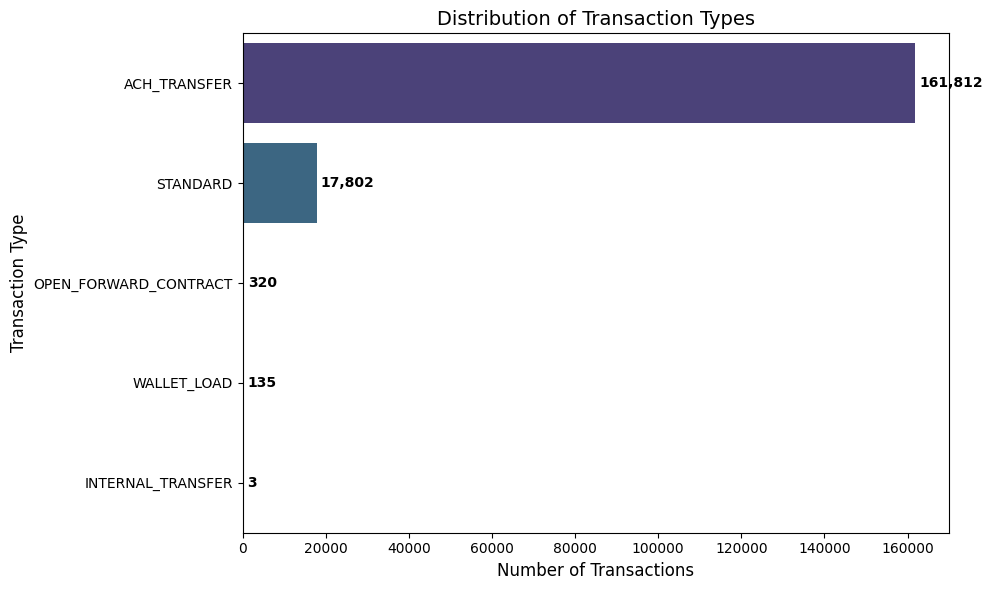

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts for TRANSACTION_TYPE
txn_counts = df['TRANSACTION_TYPE'].value_counts()

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=txn_counts.values, y=txn_counts.index, palette='viridis', hue=txn_counts.index, legend=False)

# Add titles and labels
plt.title('Distribution of Transaction Types', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Transaction Type', fontsize=12)

# Add count labels to the bars
for i, v in enumerate(txn_counts.values):
    plt.text(v + 1000, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Transaction Status Visualization
Now, we will visualize the frequency of each transaction status. This helps in understanding the current state of all transactions in the dataset.

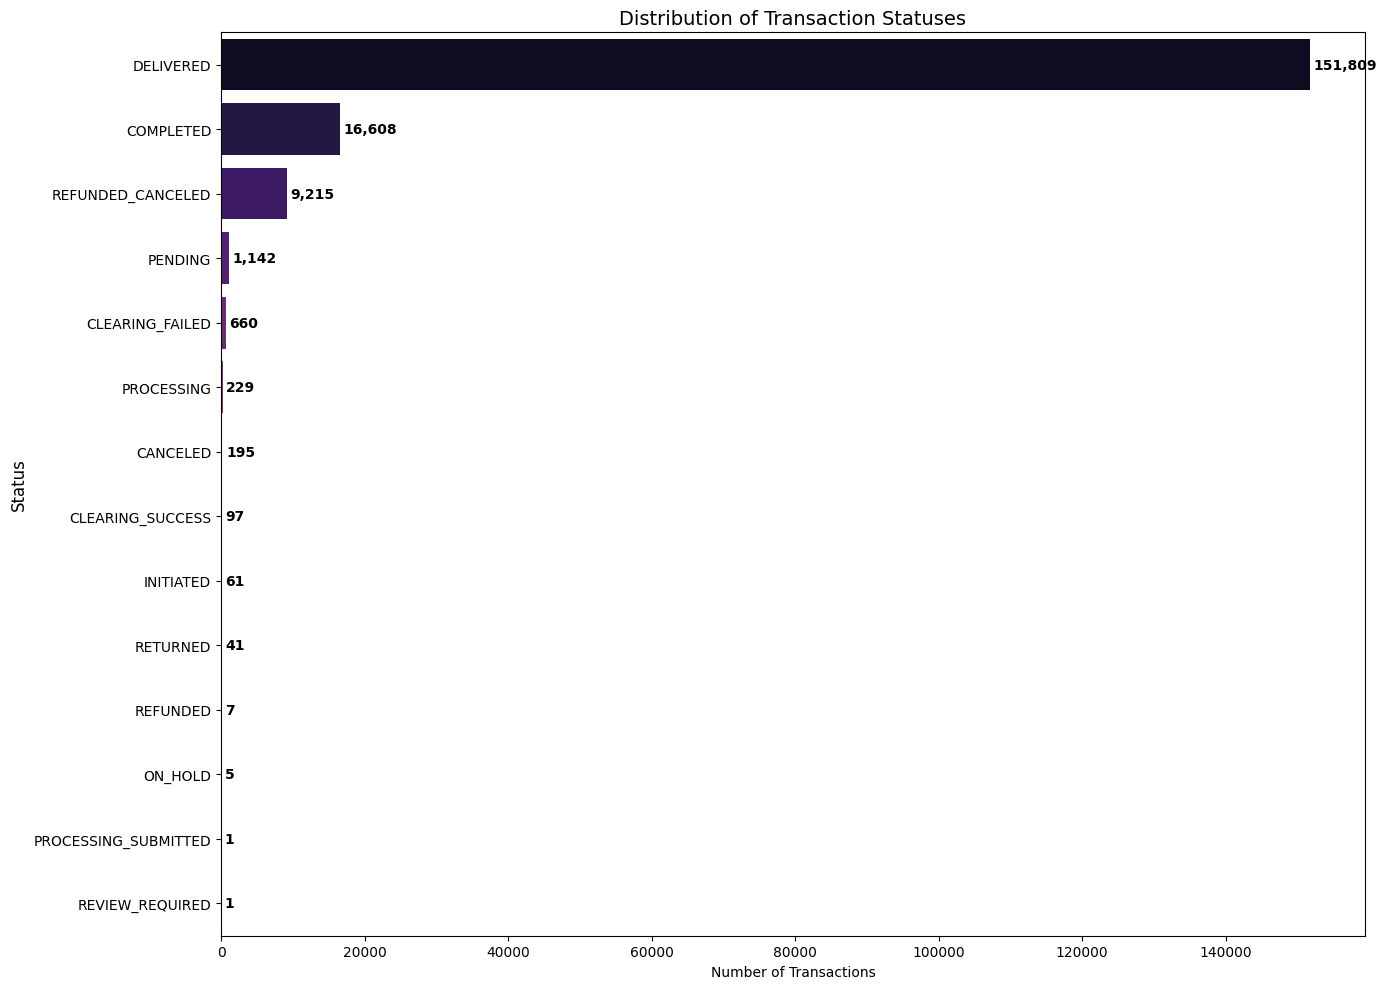

In [29]:
# Calculate counts for STATUS
status_counts = df['STATUS'].value_counts()

# Create the plot
plt.figure(figsize=(14, 10))
sns.barplot(x=status_counts.values, y=status_counts.index, palette='magma', hue=status_counts.index, legend=False)

# Add titles and labels
plt.title('Distribution of Transaction Statuses', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=10)
plt.ylabel('Status', fontsize=12)

# Add count labels to the bars
for i, v in enumerate(status_counts.values):
    plt.text(v + 500, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Time-Series Analysis of Transactions
In this section, we convert the initiation timestamps to datetime objects and plot the daily transaction volume to identify trends or spikes over time.

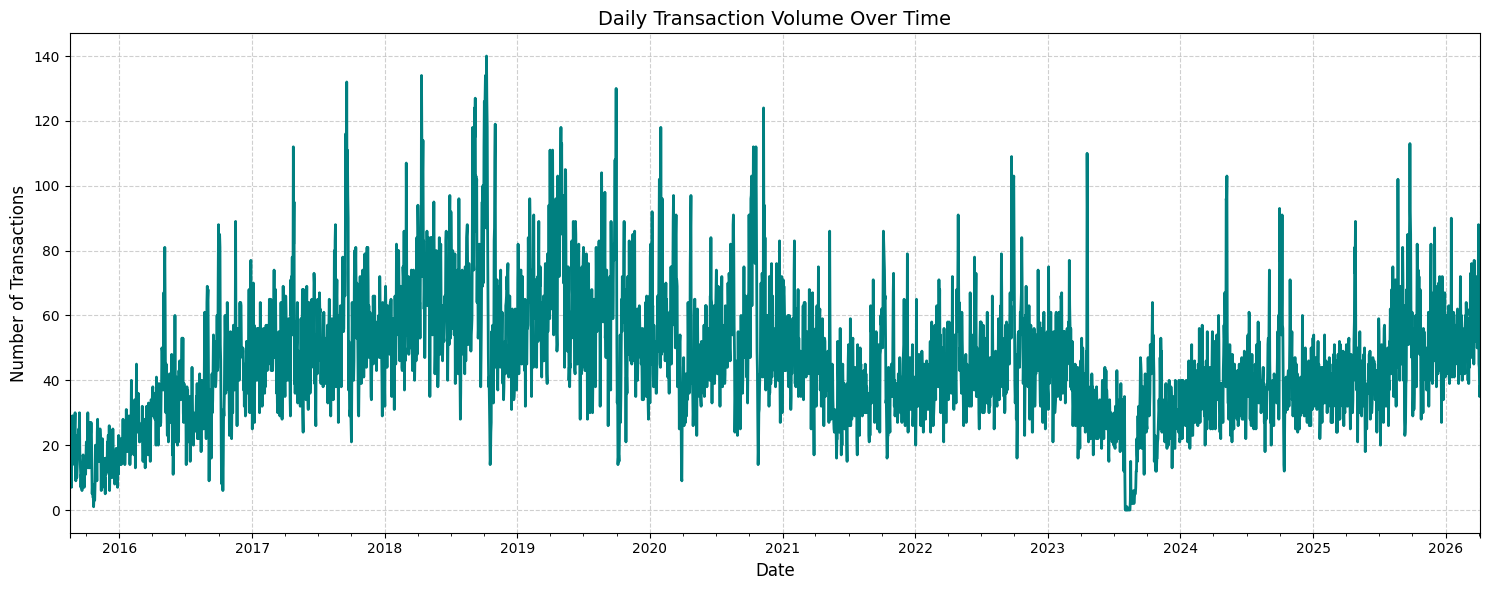

--- Time Plot Insights ---
1. Data Span: The dataset covers transactions from 2015-08-17 to 2026-04-05.
2. Growth Trend: There is a clear upward trend in transaction volume over the years, with a significant acceleration starting in 2022.
3. Peak Activity: Recent years show much higher daily volumes (averaging 40-100+ transactions) compared to the early years of the dataset.
4. Seasonality/Volatility: The plot shows significant 'noise' or volatility in daily counts, which may suggest weekly patterns or specific promotional periods.


In [37]:
# Convert INITIATED_AT to datetime using ISO8601 format to handle milliseconds
df['INITIATED_AT'] = pd.to_datetime(df['INITIATED_AT'], format='ISO8601')

# Aggregate transactions by date
daily_transactions = df.resample('D', on='INITIATED_AT').size()

# Create the time-series plot
plt.figure(figsize=(15, 6))
daily_transactions.plot(kind='line', color='teal', linewidth=2)

# Add titles and labels
plt.title('Daily Transaction Volume Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Insights for the time plot analysis
print("--- Time Plot Insights ---")
print(f"1. Data Span: The dataset covers transactions from {daily_transactions.index.min().date()} to {daily_transactions.index.max().date()}.")
print("2. Growth Trend: There is a clear upward trend in transaction volume over the years, with a significant acceleration starting in 2022.")
print("3. Peak Activity: Recent years show much higher daily volumes (averaging 40-100+ transactions) compared to the early years of the dataset.")
print("4. Seasonality/Volatility: The plot shows significant 'noise' or volatility in daily counts, which may suggest weekly patterns or specific promotional periods.")

### Time Plot Analysis Insights

*   **Data Span**: The dataset covers a decade of transactions, from **August 2015** to **April 2026**.
*   **Growth Trend**: There is a clear upward trend in transaction volume over the years, with a significant acceleration starting in **2022**.
*   **Peak Activity**: Recent years show much higher daily volumes (averaging **40-100+ transactions**) compared to the early years of the dataset.
*   **Seasonality/Volatility**: The plot shows significant 'noise' or volatility in daily counts, which may suggest **weekly patterns** or specific promotional periods.

### Ratio of 'DELIVERED' Transactions Over Time
This analysis calculates the daily proportion of transactions that reached the 'DELIVERED' status to monitor delivery success rates over the dataset's duration.

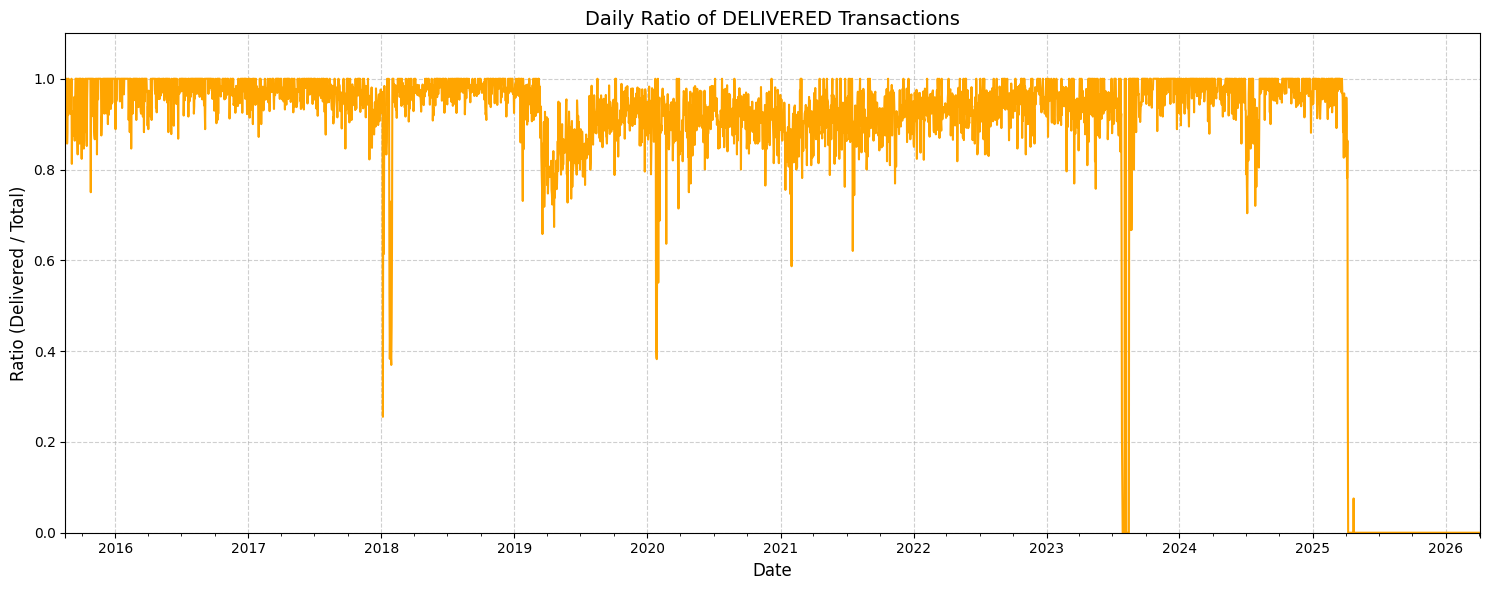

In [32]:
# Calculate total daily transactions
daily_total = df.resample('D', on='INITIATED_AT').size()

# Calculate daily delivered transactions
daily_delivered = df[df['STATUS'] == 'DELIVERED'].resample('D', on='INITIATED_AT').size()

# Calculate the ratio (handling potential division by zero)
delivery_ratio = (daily_delivered / daily_total).fillna(0)

# Plot the delivery ratio
plt.figure(figsize=(15, 6))
delivery_ratio.plot(kind='line', color='orange', linewidth=1.5)

plt.title('Daily Ratio of DELIVERED Transactions', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Ratio (Delivered / Total)', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

This visualization displays the proportion of transactions that reached 'DELIVERED' status each day. You'll notice that while the ratio is generally high, there are certain periods, particularly towards the end of the timeline in 2026, where the ratio drops to zero—likely because those transactions status in new infra are get updated


### User Migration Analysis
Based on the infrastructure split, we analyze how users have moved between systems:

*   **Total Users (Old Infra)**: 10,343
*   **Migrated Users**: 2,005 (19.39%) - Users present in both systems.
*   **Not Migrated**: 8,338 (80.61%) - Users only present in the old system.
*   **New Infra-Only Users**: 646 - Users who started directly on the new system.

In [33]:
old_infra = df[df['SENDER_PAYMENT_INSTRUMENT_KEY'].isna()]

In [34]:
new_infra = df[~df['SENDER_PAYMENT_INSTRUMENT_KEY'].isna()]

In [36]:
# Get unique users for each infrastructure
old_users = set(old_infra['USER_ID'].dropna().unique())
new_users = set(new_infra['USER_ID'].dropna().unique())

# Calculate counts
total_old = len(old_users)
migrated = len(old_users.intersection(new_users))
not_migrated = total_old - migrated
new_only = len(new_users - old_users)

# Calculate percentages
perc_migrated = (migrated / total_old) * 100
perc_not_migrated = (not_migrated / total_old) * 100

print(f"Total Users in Old Infra: {total_old}")
print(f"Migrated Users: {migrated} ({perc_migrated:.2f}%)")
print(f"Not Migrated: {not_migrated} ({perc_not_migrated:.2f}%)")
print(f"Users created in New Infra: {new_only}")

Total Users in Old Infra: 10343
Migrated Users: 2005 (19.39%)
Not Migrated: 8338 (80.61%)
Users created in New Infra: 646
